In [1]:
# --- [CELL 0]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 1}
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

In [2]:
# --- [CELL 1]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 2}
df = pd.read_csv('data/iris-data.csv')

In [3]:
# --- [CELL 2]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 3}
#Removing all null values row
df = df.dropna(subset=['petal_width_cm'])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 145 entries, 0 to 149
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   sepal_length_cm  145 non-null    float64
 1   sepal_width_cm   145 non-null    float64
 2   petal_length_cm  145 non-null    float64
 3   petal_width_cm   145 non-null    float64
 4   class            145 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.8+ KB


In [4]:
# --- [CELL 3]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 4}
df['class'].replace(["Iris-setossa","versicolor"], ["Iris-setosa","Iris-versicolor"], inplace=True)
df['class'].value_counts()

class
Iris-versicolor    50
Iris-virginica     50
Iris-setosa        45
Name: count, dtype: int64

In [5]:
# --- [CELL 4]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 5}
final_df = df[df['class'] != 'Iris-virginica']

array([[<Axes: title={'center': 'sepal_length_cm'}>]], dtype=object)

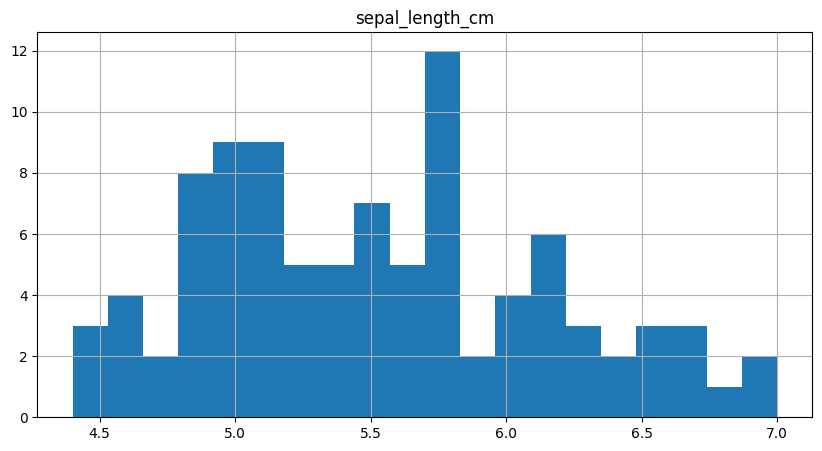

In [6]:
# --- [CELL 5]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 6}
final_df.loc[final_df.sepal_length_cm < 1, ['sepal_length_cm']] = final_df['sepal_length_cm']*100
final_df.hist(column = 'sepal_length_cm',bins=20, figsize=(10,5))

In [7]:
# --- [CELL 6]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 7}
final_df = final_df.drop(final_df[(final_df['class'] == "Iris-setosa") & (final_df['sepal_width_cm'] < 2.5)].index)

In [8]:
# --- [CELL 7]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 8}
final_df['class'].replace(["Iris-setosa","Iris-versicolor"], [1,0], inplace=True)

In [9]:
# --- [CELL 8]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 9}
inp_df = final_df.drop(final_df.columns[[4]], axis=1)
out_df = final_df.drop(final_df.columns[[0,1,2,3]], axis=1)
#
scaler = StandardScaler()
inp_df = scaler.fit_transform(inp_df)
#
X_train, X_test, y_train, y_test = train_test_split(inp_df, out_df, test_size=0.2, random_state=42)

In [10]:
# --- [CELL 9]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 10}
X_tr_arr = X_train
X_ts_arr = X_test
y_tr_arr= y_train.values
y_ts_arr = y_test.values

In [11]:
# --- [CELL 10]: ---
# cell_state: edited
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 11}
# === BEFORE (original) ===
# def weightInitialization(n_features):
#     w = np.zeros((1,n_features))
#     b = 0
#     return w,b

# === AFTER (edited) ===
def weightInitialization(n_features):
    w = np.zeros((n_features, 1))
    b = 0
    return w, b

In [12]:
# --- [CELL 11]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 12}
def sigmoid_activation(result):
    final_result = 1/(1+np.exp(-result))
    return final_result

In [13]:
# --- [CELL 12]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 13}
def model_optimize(w, b, X, Y):
    m = X.shape[0]
    
    #Prediction
    final_result = sigmoid_activation(np.dot(w,X.T)+b)
    Y_T = Y.T
    cost = (-1/m)*(np.sum((Y_T*np.log(final_result)) + ((1-Y_T)*(np.log(1-final_result)))))
    #
    
    #Gradient calculation
    dw = (1/m)*(np.dot(X.T, (final_result-Y.T).T))
    db = (1/m)*(np.sum(final_result-Y.T))
    
    grads = {"dw": dw, "db": db}
    
    return grads, cost

In [14]:
# --- [CELL 13]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 14}
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def initialize_params(dim):
    w = np.zeros((dim, 1))
    b = 0
    return w, b

def model_optimize(w, b, X, Y):
    m = X.shape[0]
    
    # Prediction
    final_result = sigmoid(np.dot(X, w) + b)
    cost = (-1/m) * np.sum(Y * np.log(final_result) + (1 - Y) * np.log(1 - final_result))
    
    # Gradient calculation
    dw = (1/m) * np.dot(X.T, (final_result - Y))
    db = (1/m) * np.sum(final_result - Y)
    
    grads = {"dw": dw, "db": db}
    
    return grads, cost

def model_train(X, Y, num_iterations, learning_rate):
    costs = []
    w, b = initialize_params(X.shape[1])
    
    for i in range(num_iterations):
        grads, cost = model_optimize(w, b, X, Y)
        
        dw = grads["dw"]
        db = grads["db"]
        
        w = w - learning_rate * dw
        b = b - learning_rate * db
        
        if i % 100 == 0:
            costs.append(cost)
            print("Cost after iteration %i: %f" % (i, cost))
    
    params = {"w": w, "b": b}
    grads = {"dw": dw, "db": db}
    
    return params, grads, costs

In [15]:
# --- [CELL 14]: ---
# cell_state: edited
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 15}
# === BEFORE (original) ===
# def model_predict(w, b, X, Y, learning_rate, no_iterations):
#     costs = []
#     for i in range(no_iterations):
#         #
#         grads, cost = model_optimize(w,b,X,Y)
#         #
#         dw = grads["dw"]
#         db = grads["db"]
#         #weight update
#         w = w - (learning_rate * (dw.T))
#         b = b - (learning_rate * db)
#         #
#         
#         if (i % 100 == 0):
#             costs.append(cost)
#             #print("Cost after %i iteration is %f" %(i, cost))
#     
#     #final parameters
#     coeff = {"w": w, "b": b}
#     gradient = {"dw": dw, "db": db}
#     
#     return coeff, gradient, costs

# === AFTER (edited) ===
def model_predict(w, b, X, Y, learning_rate, no_iterations):
    costs = []
    for i in range(no_iterations):

        grads, cost = model_optimize(w, b, X, Y)

        dw = grads["dw"]
        db = grads["db"]

        # Keep w as column vector (n_features, 1) to match model_optimize and prediction math
        w = w - (learning_rate * dw)
        b = b - (learning_rate * db)

        if (i % 100 == 0):
            costs.append(cost)

    coeff = {"w": w, "b": b}
    gradient = {"dw": dw, "db": db}

    return coeff, gradient, costs

In [16]:
# --- [CELL 15]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 16}
def predict(final_pred, m):
    y_pred = np.zeros((1,m))
    for i in range(final_pred.shape[1]):
        if final_pred[0][i] > 0.5:
            y_pred[0][i] = 1
    return y_pred

In [17]:
# --- [CELL 16]: ---
# cell_state: edited
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 17}
# === BEFORE (original) ===
# #Get number of features
# n_features = X_tr_arr.shape[1]
# print('Number of Features', n_features)
# w, b = weightInitialization(n_features)
# #Gradient Descent
# coeff, gradient, costs = model_predict(w, b, X_tr_arr, y_tr_arr, learning_rate=0.0001,no_iterations=4500)
# #Final prediction
# w = coeff["w"]
# b = coeff["b"]
# print('Optimized weights', w)
# print('Optimized intercept',b)
# #
# final_train_pred = sigmoid_activation(np.dot(w,X_tr_arr.T)+b)
# final_test_pred = sigmoid_activation(np.dot(w,X_ts_arr.T)+b)
# #
# m_tr =  X_tr_arr.shape[0]
# m_ts =  X_ts_arr.shape[0]
# #
# y_tr_pred = predict(final_train_pred, m_tr)
# print('Training Accuracy',accuracy_score(y_tr_pred.T, y_tr_arr))
# #
# y_ts_pred = predict(final_test_pred, m_ts)
# print('Test Accuracy',accuracy_score(y_ts_pred.T, y_ts_arr))

# === AFTER (edited) ===
n_features = X_tr_arr.shape[1]
print('Number of Features', n_features)
w, b = weightInitialization(n_features)

coeff, gradient, costs = model_predict(w, b, X_tr_arr, y_tr_arr, learning_rate=0.0001,no_iterations=4500)

w = coeff["w"]
b = coeff["b"]
print('Optimized weights', w)
print('Optimized intercept',b)

final_train_pred = sigmoid_activation(np.dot(X_tr_arr, w)+b)
final_test_pred = sigmoid_activation(np.dot(X_ts_arr, w)+b)

m_tr =  X_tr_arr.shape[0]
m_ts =  X_ts_arr.shape[0]

y_tr_pred = predict(final_train_pred.T, m_tr)
print('Training Accuracy',accuracy_score(y_tr_pred.T, y_tr_arr))

y_ts_pred = predict(final_test_pred.T, m_ts)
print('Test Accuracy',accuracy_score(y_ts_pred.T, y_ts_arr))

Number of Features 4
Optimized weights [[-0.13397714]
 [ 0.13130132]
 [-0.18248682]
 [-0.18319564]]
Optimized intercept -0.02413463192134359
Training Accuracy 1.0
Test Accuracy 1.0


In [18]:
import numpy as np

n_features = X_tr_arr.shape[1]
X_sample = X_tr_arr[:5]
Y_sample = y_tr_arr[:5]

# Manually construct the input shape model_optimize must handle
w_row = np.zeros((1, n_features))
b0 = 0.0

grads, cost = model_optimize(w_row, b0, X_sample, Y_sample)

assert isinstance(grads, dict)
assert "dw" in grads and "db" in grads
assert grads["dw"].shape == (n_features, 1)
assert np.isfinite(grads["dw"]).all()
assert np.isfinite(float(grads["db"]))
assert np.isfinite(float(cost))

ValueError: shapes (5,4) and (1,4) not aligned: 4 (dim 1) != 1 (dim 0)